In [1]:
# ==========================================
# FIFA World Cup 2026 - K-Means Clustering
# Cell 1: Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import silhouette_score

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ==========================================
# Cell 2: Load Dataset
# ==========================================

# Load the dataset
df = pd.read_csv("cleaned_fifa_dataset.csv")

# Display first 5 rows
df.head()

,num__match_id,num__stage_id,num__venue_id,num__home_team_id,num__away_team_id,num__home_score,num__away_score,num__home_xg,num__away_xg,num__referee_id,cat__date_2026-06-11,cat__date_2026-06-12,cat__date_2026-06-13,cat__date_2026-06-14,cat__date_2026-06-15,cat__date_2026-06-16,cat__date_2026-06-17,cat__date_2026-06-18,cat__date_2026-06-19,cat__date_2026-06-20,cat__date_2026-06-21,cat__date_2026-06-22,cat__date_2026-06-23,cat__date_2026-06-24,cat__date_2026-06-25,cat__date_2026-06-26,cat__date_2026-06-27,cat__date_2026-06-28,cat__date_2026-06-29,cat__kickoff_time_utc_15:00,cat__kickoff_time_utc_18:00,cat__kickoff_time_utc_19:00,cat__kickoff_time_utc_21:00,cat__kickoff_time_utc_22:00,cat__kickoff_time_utc_23:00,cat__kickoff_time_utc_23:59,cat__status_Completed,cat__status_Scheduled
0,-1.708159,0.0,-1.631250,-1.694863,-1.625562,-0.165220,-1.732051,-0.148084,-1.513882,-1.537729,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.660042,0.0,-0.370606,-1.550620,-1.481068,-0.165220,0.000000,-0.821867,0.177156,-1.319783,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.611925,0.0,-0.580713,-1.406376,-1.336574,-1.090450,0.000000,-0.994632,-0.217419,-1.101837,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.563808,0.0,-1.211035,-0.829401,-0.758596,1.685241,0.000000,1.441352,-0.499259,-0.883891,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.515691,0.0,0.259716,-1.262132,-1.192079,-1.090450,0.000000,-1.979391,1.360883,-0.665945,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
# ==========================================
# Cell 3: Dataset Overview
# ==========================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (72, 38)

Column Names:
['num__match_id', 'num__stage_id', 'num__venue_id', 'num__home_team_id', 'num__away_team_id', 'num__home_score', 'num__away_score', 'num__home_xg', 'num__away_xg', 'num__referee_id', 'cat__date_2026-06-11', 'cat__date_2026-06-12', 'cat__date_2026-06-13', 'cat__date_2026-06-14', 'cat__date_2026-06-15', 'cat__date_2026-06-16', 'cat__date_2026-06-17', 'cat__date_2026-06-18', 'cat__date_2026-06-19', 'cat__date_2026-06-20', 'cat__date_2026-06-21', 'cat__date_2026-06-22', 'cat__date_2026-06-23', 'cat__date_2026-06-24', 'cat__date_2026-06-25', 'cat__date_2026-06-26', 'cat__date_2026-06-27', 'cat__date_2026-06-28', 'cat__date_2026-06-29', 'cat__kickoff_time_utc_15:00', 'cat__kickoff_time_utc_18:00', 'cat__kickoff_time_utc_19:00', 'cat__kickoff_time_utc_21:00', 'cat__kickoff_time_utc_22:00', 'cat__kickoff_time_utc_23:00', 'cat__kickoff_time_utc_23:59', 'cat__status_Completed', 'cat__status_Scheduled']

Dataset Information:
<class 'pandas.DataFrame'>
RangeI

In [5]:
# ==========================================
# Cell 4: Statistical Summary
# ==========================================

df.describe(include="all")

,num__match_id,num__stage_id,num__venue_id,num__home_team_id,num__away_team_id,num__home_score,num__away_score,num__home_xg,num__away_xg,num__referee_id,cat__date_2026-06-11,cat__date_2026-06-12,cat__date_2026-06-13,cat__date_2026-06-14,cat__date_2026-06-15,cat__date_2026-06-16,cat__date_2026-06-17,cat__date_2026-06-18,cat__date_2026-06-19,cat__date_2026-06-20,cat__date_2026-06-21,cat__date_2026-06-22,cat__date_2026-06-23,cat__date_2026-06-24,cat__date_2026-06-25,cat__date_2026-06-26,cat__date_2026-06-27,cat__date_2026-06-28,cat__date_2026-06-29,cat__kickoff_time_utc_15:00,cat__kickoff_time_utc_18:00,cat__kickoff_time_utc_19:00,cat__kickoff_time_utc_21:00,cat__kickoff_time_utc_22:00,cat__kickoff_time_utc_23:00,cat__kickoff_time_utc_23:59,cat__status_Completed,cat__status_Scheduled
count,7.200000e+01,72.0,7.200000e+01,7.200000e+01,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,-1.233581e-17,0.0,-4.934325e-17,2.467162e-17,0.000000,4.934325e-17,3.083953e-18,5.057683e-16,6.476301e-16,9.868649e-17,0.027778,0.027778,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.152778,0.319444,0.027778,0.152778,0.166667,0.027778,0.152778,0.388889,0.611111
std,1.007018e+00,0.0,1.007018e+00,1.007018e+00,1.007018,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,0.165489,0.165489,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.230669,0.362298,0.469533,0.165489,0.362298,0.375293,0.165489,0.362298,0.490919,0.490919
min,-1.708159e+00,0.0,-1.631250e+00,-1.694863e+00,-1.697810,-2.015680e+00,-1.732051e+00,-2.152156e+00,-2.359401e+00,-1.537729e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.540797e-01,0.0,-1.000928e+00,-8.474317e-01,-0.848905,-1.652197e-01,0.000000e+00,3.836149e-16,6.258099e-16,-8.838913e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000e+00,0.0,4.960867e-02,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,3.836149e-16,6.258099e-16,-1.210810e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,8.540797e-01,0.0,8.900378e-01,8.474317e-01,0.848905,0.000000e+00,0.000000e+00,3.836149e-16,6.258099e-16,8.596751e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.708159e+00,0.0,1.520360e+00,1.694863e+00,1.697810,4.460931e+00,5.196152e+00,5.000306e+00,5.052983e+00,1.731458e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# ==========================================
# Cell 5: Select Numerical Features
# ==========================================

# Keep only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Numerical Features Used:")

for col in numeric_df.columns:
    print(col)

numeric_df.head()

Numerical Features Used:
num__match_id
num__stage_id
num__venue_id
num__home_team_id
num__away_team_id
num__home_score
num__away_score
num__home_xg
num__away_xg
num__referee_id
cat__date_2026-06-11
cat__date_2026-06-12
cat__date_2026-06-13
cat__date_2026-06-14
cat__date_2026-06-15
cat__date_2026-06-16
cat__date_2026-06-17
cat__date_2026-06-18
cat__date_2026-06-19
cat__date_2026-06-20
cat__date_2026-06-21
cat__date_2026-06-22
cat__date_2026-06-23
cat__date_2026-06-24
cat__date_2026-06-25
cat__date_2026-06-26
cat__date_2026-06-27
cat__date_2026-06-28
cat__date_2026-06-29
cat__kickoff_time_utc_15:00
cat__kickoff_time_utc_18:00
cat__kickoff_time_utc_19:00
cat__kickoff_time_utc_21:00
cat__kickoff_time_utc_22:00
cat__kickoff_time_utc_23:00
cat__kickoff_time_utc_23:59
cat__status_Completed
cat__status_Scheduled


,num__match_id,num__stage_id,num__venue_id,num__home_team_id,num__away_team_id,num__home_score,num__away_score,num__home_xg,num__away_xg,num__referee_id,cat__date_2026-06-11,cat__date_2026-06-12,cat__date_2026-06-13,cat__date_2026-06-14,cat__date_2026-06-15,cat__date_2026-06-16,cat__date_2026-06-17,cat__date_2026-06-18,cat__date_2026-06-19,cat__date_2026-06-20,cat__date_2026-06-21,cat__date_2026-06-22,cat__date_2026-06-23,cat__date_2026-06-24,cat__date_2026-06-25,cat__date_2026-06-26,cat__date_2026-06-27,cat__date_2026-06-28,cat__date_2026-06-29,cat__kickoff_time_utc_15:00,cat__kickoff_time_utc_18:00,cat__kickoff_time_utc_19:00,cat__kickoff_time_utc_21:00,cat__kickoff_time_utc_22:00,cat__kickoff_time_utc_23:00,cat__kickoff_time_utc_23:59,cat__status_Completed,cat__status_Scheduled
0,-1.708159,0.0,-1.631250,-1.694863,-1.625562,-0.165220,-1.732051,-0.148084,-1.513882,-1.537729,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.660042,0.0,-0.370606,-1.550620,-1.481068,-0.165220,0.000000,-0.821867,0.177156,-1.319783,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.611925,0.0,-0.580713,-1.406376,-1.336574,-1.090450,0.000000,-0.994632,-0.217419,-1.101837,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.563808,0.0,-1.211035,-0.829401,-0.758596,1.685241,0.000000,1.441352,-0.499259,-0.883891,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.515691,0.0,0.259716,-1.262132,-1.192079,-1.090450,0.000000,-1.979391,1.360883,-0.665945,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [7]:
scaler = StandardScaler()

X = scaler.fit_transform(numeric_df)

print(X.shape)

(72, 38)


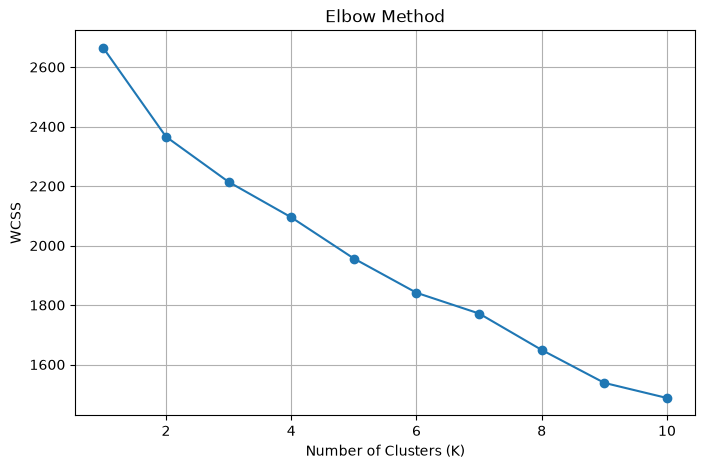

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [9]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

df.head()

,num__match_id,num__stage_id,num__venue_id,num__home_team_id,num__away_team_id,num__home_score,num__away_score,num__home_xg,num__away_xg,num__referee_id,cat__date_2026-06-11,cat__date_2026-06-12,cat__date_2026-06-13,cat__date_2026-06-14,cat__date_2026-06-15,cat__date_2026-06-16,cat__date_2026-06-17,cat__date_2026-06-18,cat__date_2026-06-19,cat__date_2026-06-20,cat__date_2026-06-21,cat__date_2026-06-22,cat__date_2026-06-23,cat__date_2026-06-24,cat__date_2026-06-25,cat__date_2026-06-26,cat__date_2026-06-27,cat__date_2026-06-28,cat__date_2026-06-29,cat__kickoff_time_utc_15:00,cat__kickoff_time_utc_18:00,cat__kickoff_time_utc_19:00,cat__kickoff_time_utc_21:00,cat__kickoff_time_utc_22:00,cat__kickoff_time_utc_23:00,cat__kickoff_time_utc_23:59,cat__status_Completed,cat__status_Scheduled,Cluster
0,-1.708159,0.0,-1.631250,-1.694863,-1.625562,-0.165220,-1.732051,-0.148084,-1.513882,-1.537729,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
1,-1.660042,0.0,-0.370606,-1.550620,-1.481068,-0.165220,0.000000,-0.821867,0.177156,-1.319783,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
2,-1.611925,0.0,-0.580713,-1.406376,-1.336574,-1.090450,0.000000,-0.994632,-0.217419,-1.101837,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
3,-1.563808,0.0,-1.211035,-0.829401,-0.758596,1.685241,0.000000,1.441352,-0.499259,-0.883891,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
4,-1.515691,0.0,0.259716,-1.262132,-1.192079,-1.090450,0.000000,-1.979391,1.360883,-0.665945,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2


In [10]:

df["Cluster"].value_counts().sort_index()

Cluster
0    44
1    15
2    13
Name: count, dtype: int64

In [11]:
score = silhouette_score(X, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.13579162535045455


In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-5.432499,-2.743437,2
1,-4.657976,-1.175819,2
2,-4.559639,-0.981496,2
3,-4.421225,-1.452769,2
4,-2.896122,1.244796,2


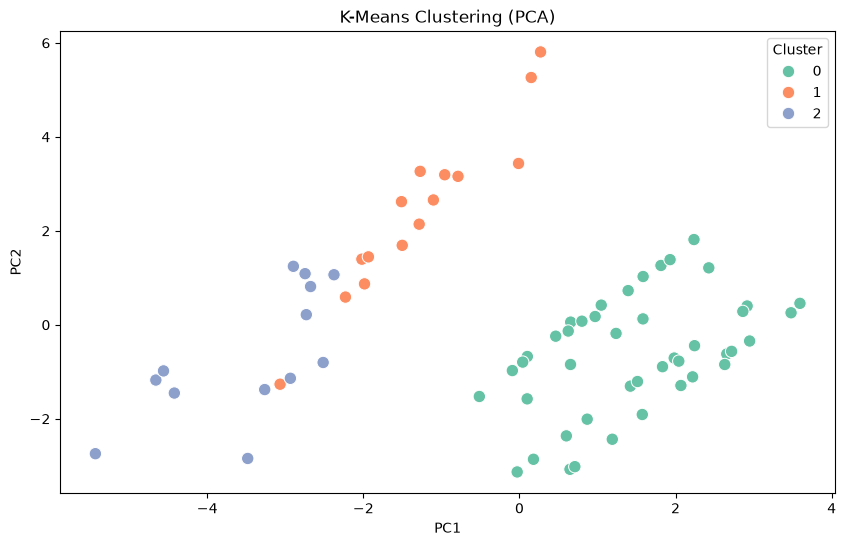

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("K-Means Clustering (PCA)")
plt.show()

In [14]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,num__match_id,num__stage_id,num__venue_id,num__home_team_id,num__away_team_id,num__home_score,num__away_score,num__home_xg,num__away_xg,num__referee_id,cat__date_2026-06-11,cat__date_2026-06-12,cat__date_2026-06-13,cat__date_2026-06-14,cat__date_2026-06-15,cat__date_2026-06-16,cat__date_2026-06-17,cat__date_2026-06-18,cat__date_2026-06-19,cat__date_2026-06-20,cat__date_2026-06-21,cat__date_2026-06-22,cat__date_2026-06-23,cat__date_2026-06-24,cat__date_2026-06-25,cat__date_2026-06-26,cat__date_2026-06-27,cat__date_2026-06-28,cat__date_2026-06-29,cat__kickoff_time_utc_15:00,cat__kickoff_time_utc_18:00,cat__kickoff_time_utc_19:00,cat__kickoff_time_utc_21:00,cat__kickoff_time_utc_22:00,cat__kickoff_time_utc_23:00,cat__kickoff_time_utc_23:59,cat__status_Completed,cat__status_Scheduled
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.673640,0.0,0.059159,0.150800,0.111655,0.00000,0.000000,3.836149e-16,6.258099e-16,0.057238,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.090909,0.113636,0.386364,0.000000,0.113636,0.272727,0.000000,0.113636,0.0,1.0
1,-0.944700,0.0,0.189680,0.603419,0.676716,0.14319,0.577350,2.492749e-01,4.608750e-01,0.060540,0.000000,0.000000,0.000000,0.200000,0.266667,0.266667,0.266667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266667,0.266667,0.000000,0.200000,0.000000,0.000000,0.266667,1.0,0.0
2,-1.189974,0.0,-0.419092,-1.206654,-1.158734,-0.16522,-0.666173,-2.876249e-01,-5.317789e-01,-0.263584,0.153846,0.153846,0.307692,0.076923,0.000000,0.000000,0.000000,0.307692,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153846,0.153846,0.153846,0.230769,0.000000,0.153846,0.153846,1.0,0.0


In [15]:
df.to_csv("fifa_clustered.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
